# Customer Segmentation using RFM + K-Means

## Project Objective
The goal of this project is to segment customers based on their purchasing behavior using **RFM Analysis** and **K-Means Clustering**.

### Project workflow
**Transactions → RFM → Scaling → Elbow & Silhouette → K-Means → PCA → Customer Personas**

We will evaluate the clustering choices using quantitative evidence and then translate the clusters into meaningful business personas.

## 1. Import Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)

In [19]:
from google.colab import files
uploaded=files.upload()

Saving retail_transactions_segmentation.csv to retail_transactions_segmentation (1).csv


## 2. Load Dataset

The required dataset is `01-ml-project/retail_transactions_segmentation.csv`.

The first path below is the **repository path** expected by the project. The second path is only a local fallback so the notebook can also be tested with the uploaded CSV outside the repository.

In [20]:

import pandas as pd

df = pd.read_csv("retail_transactions_segmentation.csv")
df.head()

,customer_id,transaction_date,amount,product_category
0,5206,2024-01-31,162.65,Fashion
1,5153,2024-07-03,389.85,Fashion
2,5102,2024-11-13,453.72,Home & Living
3,5073,2024-03-11,824.74,Electronics
4,5097,2024-12-28,181.74,Sports


## 3. Data Exploration

In [21]:
print("Shape:", df.shape)
print("Number of unique customers:", df["customer_id"].nunique())
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nSummary statistics:")
display(df.describe(include="all"))

Shape: (3663, 4)
Number of unique customers: 300

Columns:
['customer_id', 'transaction_date', 'amount', 'product_category']

Data types:
customer_id           int64
transaction_date     object
amount              float64
product_category     object
dtype: object

Missing values:
customer_id         0
transaction_date    0
amount              0
product_category    0
dtype: int64

Summary statistics:


,customer_id,transaction_date,amount,product_category
count,3663.000000,3663,3663.000000,3663
unique,NaN,360,NaN,6
top,NaN,2024-11-21,NaN,Groceries
freq,NaN,24,NaN,640
mean,5147.309036,NaN,513.028376,NaN
std,85.189230,NaN,305.332100,NaN
min,5001.000000,NaN,5.000000,NaN
25%,5073.000000,NaN,276.550000,NaN
50%,5142.000000,NaN,411.870000,NaN
75%,5223.000000,NaN,767.740000,NaN


In [22]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

print("Minimum transaction date:", df["transaction_date"].min().date())
print("Maximum transaction date:", df["transaction_date"].max().date())

print("\nDuplicate rows:", df.duplicated().sum())

Minimum transaction date: 2024-01-01
Maximum transaction date: 2024-12-30

Duplicate rows: 0


# Point 1 — RFM Feature Table

RFM summarizes each customer's behavior using three features:

- **Recency:** number of days since the customer's most recent purchase. Lower is better.
- **Frequency:** number of transactions made by the customer. Higher is better.
- **Monetary:** total amount spent by the customer. Higher is better.

### Reference date
We use **one day after the latest transaction date** as the reference date. This makes the latest transaction have a Recency of 1 day and avoids treating the latest transaction as 0 days old.

### Monetary choice
For Monetary, we use **Total Spend (sum of `amount`) per customer**, because total customer value is useful for business segmentation.

In [25]:
reference_date = df["transaction_date"].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby("customer_id")
      .agg(
          Recency=("transaction_date", lambda x: (reference_date - x.max()).days),
          Frequency=("customer_id", "count"),
          Monetary=("amount", "sum")
      )
      .reset_index()
)

print("Reference date:", reference_date.date())
print("RFM shape:", rfm.shape)

display(rfm.head())
print("\nRFM shape check:", rfm.shape)

Reference date: 2024-12-31
RFM shape: (300, 4)


,customer_id,Recency,Frequency,Monetary
0,5001,2,16,5172.45
1,5002,23,18,6158.98
2,5003,37,3,654.12
3,5004,5,35,31050.88
4,5005,26,16,5700.91



RFM shape check: (300, 4)


### RFM sanity checks

The dataset contains **300 unique customers**, so the RFM table should contain exactly 300 rows and one row per customer.

In [26]:
assert rfm["customer_id"].nunique() == 300
assert len(rfm) == 300
assert rfm[["Recency", "Frequency", "Monetary"]].isna().sum().sum() == 0

print("✓ RFM contains exactly 300 customers.")
print("✓ No missing RFM values.")

✓ RFM contains exactly 300 customers.
✓ No missing RFM values.


# Point 2 — Feature Scaling

K-Means is distance-based. Monetary values can be much larger numerically than Recency or Frequency, so using the raw RFM values could make Monetary dominate the distance calculation.

Therefore, we apply **StandardScaler** before K-Means.

In [27]:
rfm_features = ["Recency", "Frequency", "Monetary"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm[rfm_features])

rfm_scaled = pd.DataFrame(
    X_scaled,
    columns=rfm_features,
    index=rfm.index
)

display(rfm_scaled.head())

print("Scaled means:")
print(rfm_scaled.mean().round(6))

print("\nScaled standard deviations:")
print(rfm_scaled.std(ddof=0).round(6))

,Recency,Frequency,Monetary
0,-0.772792,0.356692,-0.113196
1,-0.464634,0.544920,-0.010898
2,-0.259195,-0.866790,-0.581723
3,-0.728770,2.144859,2.570262
4,-0.420611,0.356692,-0.058397


Scaled means:
Recency     -0.0
Frequency   -0.0
Monetary     0.0
dtype: float64

Scaled standard deviations:
Recency      1.0
Frequency    1.0
Monetary     1.0
dtype: float64


# Point 3 — Choosing K

We test values of **K from 2 to 10** using two methods:

1. **Elbow Method:** examines K-Means inertia and looks for a point where additional clusters provide diminishing improvement.
2. **Silhouette Score:** measures how well-separated and cohesive the clusters are. Higher is better.

We use both plots together instead of choosing K arbitrarily.

In [28]:
k_values = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)

    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

k_results = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores
})

display(k_results.round(4))

,K,Inertia,Silhouette Score
0,2,394.2080,0.6789
1,3,183.0321,0.6782
2,4,93.3880,0.5702
3,5,71.4071,0.5232
4,6,50.3436,0.5194
5,7,41.1257,0.4626
6,8,30.2236,0.4815
7,9,24.1191,0.4822
8,10,21.0743,0.4765


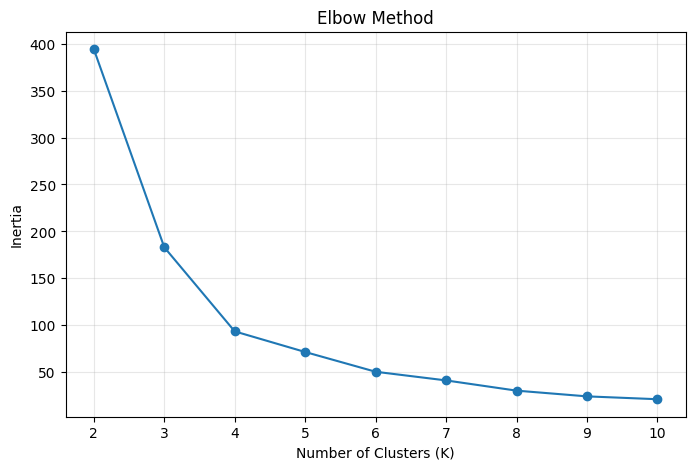

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(k_results["K"], k_results["Inertia"], marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.show()

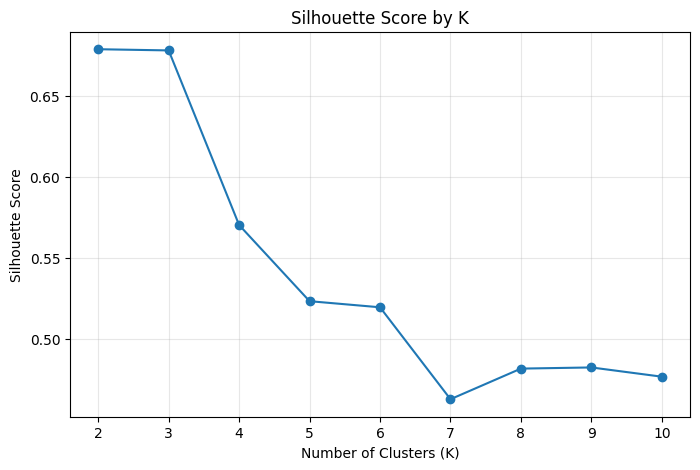

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(k_results["K"], k_results["Silhouette Score"], marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by K")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.show()

## K Selection and Interpretation

For this dataset, **K = 3** is selected.

- The Elbow curve shows a strong reduction in inertia up to the lower K values, with the improvement becoming less dramatic after the 3-cluster solution.
- The Silhouette Score for K=3 is **0.6782**, which is very close to the best score (K=2: **0.6789**) while providing a more useful business segmentation.
- K=4 and larger values reduce the silhouette score noticeably.
- Therefore, K=3 gives a strong balance between cluster quality and useful business interpretability.

**Important:** K=3 is not chosen from the business labels first; it is supported by the clustering metrics and then interpreted using the resulting RFM profiles.

# Point 4 — K-Means Clustering

In [31]:
chosen_k = 3

kmeans = KMeans(
    n_clusters=chosen_k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(X_scaled)

print("Cluster counts:")
display(rfm["Cluster"].value_counts().sort_index())

display(rfm.head())

Cluster counts:


,count
Cluster,
0,40
1,238
2,22


,customer_id,Recency,Frequency,Monetary,Cluster
0,5001,2,16,5172.45,1
1,5002,23,18,6158.98,1
2,5003,37,3,654.12,1
3,5004,5,35,31050.88,0
4,5005,26,16,5700.91,1


### Cluster RFM Profiles

We calculate the mean RFM values for each cluster. These values will be used to create the customer personas.

In [32]:
cluster_summary = (
    rfm.groupby("Cluster")[rfm_features]
       .mean()
       .round(2)
)

cluster_summary["Customers"] = rfm["Cluster"].value_counts().sort_index()

display(cluster_summary)

,Recency,Frequency,Monetary,Customers
Cluster,,,,
0,8.40,35.00,29683.61,40
1,43.59,9.32,2876.90,238
2,258.59,2.09,326.14,22


# Point 5 — PCA Visualization

RFM has three dimensions. PCA reduces the scaled RFM features from 3 dimensions to 2 principal components so we can visualize the clusters on a 2D chart.

The clustering itself is still based on the **scaled RFM features**, not on the PCA plot.

In [33]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

rfm["PC1"] = X_pca[:, 0]
rfm["PC2"] = X_pca[:, 1]

print("Explained variance ratio:")
print("PC1:", round(pca.explained_variance_ratio_[0], 4))
print("PC2:", round(pca.explained_variance_ratio_[1], 4))
print("Total explained variance:", round(pca.explained_variance_ratio_.sum(), 4))

Explained variance ratio:
PC1: 0.7503
PC2: 0.2372
Total explained variance: 0.9875


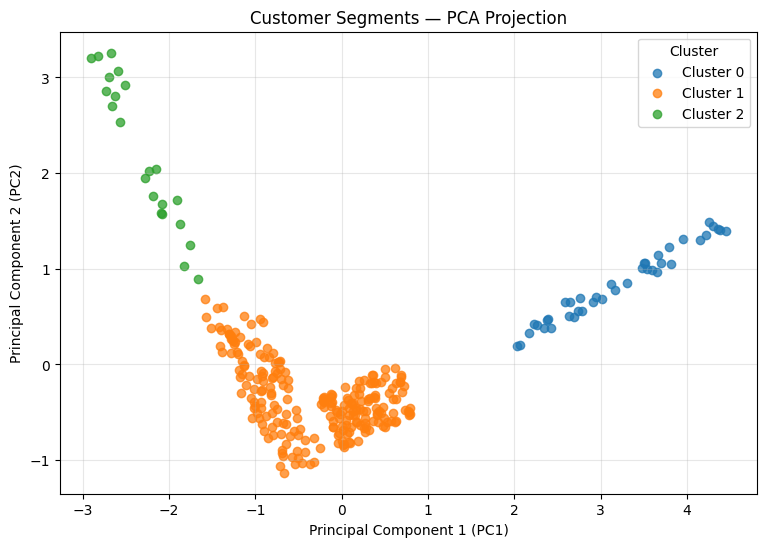

In [34]:
plt.figure(figsize=(9, 6))

for cluster in sorted(rfm["Cluster"].unique()):
    subset = rfm[rfm["Cluster"] == cluster]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.75
    )

plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.title("Customer Segments — PCA Projection")
plt.legend(title="Cluster")
plt.grid(True, alpha=0.3)
plt.show()

# Point 6 — Customer Personas

The cluster names below are assigned **after** examining the actual RFM means.

Because Recency is better when low, while Frequency and Monetary are better when high:

- A cluster with very low Recency and very high Frequency/Monetary is a high-value active segment.
- A cluster with medium Recency/Frequency/Monetary is a regular/standard segment.
- A cluster with very high Recency and low Frequency/Monetary is an inactive or dormant segment.

In [35]:
# Rank clusters by their RFM profiles to make the persona assignment reproducible.
# Best active/high-value cluster: lowest Recency + highest Frequency + highest Monetary.
# Dormant cluster: highest Recency + lowest Frequency + lowest Monetary.

cluster_summary = (
    rfm.groupby("Cluster")[rfm_features]
       .mean()
       .round(2)
)

cluster_summary["Customers"] = rfm["Cluster"].value_counts().sort_index()

display(cluster_summary.sort_index())

,Recency,Frequency,Monetary,Customers
Cluster,,,,
0,8.40,35.00,29683.61,40
1,43.59,9.32,2876.90,238
2,258.59,2.09,326.14,22


## Persona 1 — VIP / High-Value Active Customers

**Profile:** Very low Recency with very high Frequency and Monetary value.

These customers purchase recently, purchase frequently, and spend substantially more than the other segments.

**Business action:** Protect retention with loyalty rewards, exclusive offers, early access to products, and personalized recommendations.

## Persona 2 — Regular / Growing Customers

**Profile:** Medium Recency, Frequency, and Monetary value.

These customers are active but have room to increase their purchase frequency and total spend.

**Business action:** Use cross-selling, bundles, personalized promotions, and loyalty incentives to move them toward the VIP segment.

## Persona 3 — Dormant / At-Risk Customers

**Profile:** High Recency with low Frequency and Monetary value.

These customers have not purchased recently and show relatively low engagement.

**Business action:** Use targeted reactivation campaigns, limited-time offers, and low-cost reminders. Marketing spend should be controlled if they do not respond.

# Final Results

The final segmentation is based on:

**RFM → StandardScaler → Elbow + Silhouette → K-Means (K=3) → PCA → Business Personas**

The three resulting segments are:

1. **VIP / High-Value Active**
2. **Regular / Growing**
3. **Dormant / At-Risk**

The labels are business interpretations of the actual cluster RFM profiles, not inputs to the K-Means algorithm.

## Final Validation Checklist

- [x] RFM table created at customer level
- [x] 300 unique customers
- [x] Recency reference date documented
- [x] Monetary defined as total spend
- [x] StandardScaler applied before K-Means
- [x] Elbow Method evaluated for K=2..10
- [x] Silhouette Score evaluated for K=2..10
- [x] K=3 justified using both metrics and business interpretability
- [x] K-Means uses `random_state=42`
- [x] Cluster labels added to customers
- [x] PCA reduced RFM to 2 components for visualization
- [x] PCA chart contains axis labels, title, and legend
- [x] Cluster RFM means calculated
- [x] Customer personas and business actions documented